# Code to read measurements and create files to be read for comparison with model

Author: Sofia Midauar

Data: July 2024


In [17]:
import xarray as xr
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import glob2 as glob
import platform
import os
import sys
import seaborn as sns
import re
from matplotlib import dates as mpl_dates
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import calendar
from mpl_toolkits.axes_grid1 import make_axes_locatable
from datetime import datetime, timedelta
from datetime import date, timedelta

In [2]:
%config Completer.use_jedi = False

In [3]:
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Monthly data

**First sheets - WT, Sat-O2, DO, pH**

In [4]:
## Read data transforming date and time separate columns into a combined column
# Cab 01
monthly_data_CAB01 = pd.read_excel('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/CAB_data_2024/CAB_monthly_monitoring_complete.xlsx', 
                             sheet_name = "CAB_Env", parse_dates = [['Date', 'Heure']], date_format = "YYYY-MM-DD HH:MM:SS")

monthly_data_CAB01[['day','hour']] = monthly_data_CAB01['Date_Heure'].str.split(' ', expand = True)[[0,2]]
monthly_data_CAB01['time'] = monthly_data_CAB01[['day','hour']].apply(' '.join, axis=1)

monthly_data_CAB01['time'] = pd.to_datetime(monthly_data_CAB01['time'], format = '%Y-%m-%d %H:%M:%S')
monthly_data_CAB01.set_index('time', inplace = True)
monthly_data_CAB01 = monthly_data_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00'] # calibration period
monthly_data_CAB01.drop(['Date_Heure','day', 'hour'], axis = 1, inplace = True)

# BIS
monthly_data_BIS = pd.read_excel('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/CAB_data_2024/CAB_monthly_monitoring_complete.xlsx', 
                             sheet_name = "CAB_BIS_env", parse_dates = [['Date', 'Hour']], date_format = "YYYY-MM-DD HH:MM:SS")
monthly_data_BIS[['day','hour']] = monthly_data_BIS['Date_Hour'].str.split(' ', expand = True)[[0,2]]
monthly_data_BIS['time'] = monthly_data_BIS[['day','hour']].apply(' '.join, axis=1)

monthly_data_BIS['time'] = pd.to_datetime(monthly_data_BIS['time'], format = '%Y-%m-%d %H:%M:%S')
monthly_data_BIS.set_index('time', inplace = True)
monthly_data_BIS = monthly_data_BIS.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00'] # calibration period
monthly_data_BIS.drop(['Date_Hour','day', 'hour'], axis = 1, inplace = True)
monthly_data_BIS.head(2)

,Serie_ID,Site,max depth (m),Secchi (cm),Depth (m),Temperature (°C),Sat O2 (%),Con O2 (mg/L),Cond (µS/cm²),pH,Turbi (NTU)
time,,,,,,,,,,,
2022-12-12 13:50:00,1222,CAB_BIS,7.5,138,0.0,8.5,94.6,11.05,203.1,8.05,7.0
2022-12-12 13:50:00,1222,CAB_BIS,7.5,138,1.0,8.5,94.5,11.03,203.1,8.04,7.1


In [6]:
monthly_data_CAB01.to_csv('monthly_data_CAB01.csv')
monthly_data_BIS.to_csv('monthly_data_BIS.csv')

In [7]:
monthly_data_CAB01[['Depth (m)', 'Con O2 (mg/L)']].loc['2023-04-11 11:40:00']

,Depth (m),Con O2 (mg/L)
time,,
2023-04-11 11:40:00,0.0,10.43
2023-04-11 11:40:00,1.0,10.59
2023-04-11 11:40:00,2.0,10.99
2023-04-11 11:40:00,3.0,11.60
2023-04-11 11:40:00,4.0,11.70
2023-04-11 11:40:00,5.0,12.00
2023-04-11 11:40:00,6.0,11.63
2023-04-11 11:40:00,7.0,10.79
2023-04-11 11:40:00,8.0,10.67


In [10]:
monthly_data_CAB01[['Depth (m)', 'Con O2 (mg/L)']].loc['2023-04-11 11:40:00'].mean()

Depth (m)         4.000000
Con O2 (mg/L)    11.155556
dtype: float64

In [9]:
monthly_data_BIS[['Depth (m)', 'Con O2 (mg/L)']].loc['2023-05-17 12:30:00']

,Depth (m),Con O2 (mg/L)
time,,
2023-05-17 12:30:00,0.0,9.37
2023-05-17 12:30:00,1.0,9.36
2023-05-17 12:30:00,2.0,9.37
2023-05-17 12:30:00,3.0,9.37
2023-05-17 12:30:00,4.0,9.37
2023-05-17 12:30:00,5.0,9.36
2023-05-17 12:30:00,6.0,9.35
2023-05-17 12:30:00,7.0,9.36


**PAR**

In [8]:
## PAR data 
# Read data transforming date and time separate columns into a combined column
monthly_PAR_BIS = pd.read_excel('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/CAB_data_2024/CAB_monthly_monitoring_complete.xlsx', 
                                 sheet_name = "PAR", parse_dates = [['Date', 'Heure']], date_format = 'YYYY-MM-DD HH:MM:SS')
monthly_PAR_BIS.dropna(inplace = True)

# last calibration step: '2023-06-13 12:45:00'
monthly_PAR_BIS[['day','hour']] = monthly_PAR_BIS['Date_Heure'].str.split(' ', expand = True)[[0,2]]
monthly_PAR_BIS['time'] = monthly_PAR_BIS[['day','hour']].apply(' '.join, axis=1)

monthly_PAR_BIS['time'] = pd.to_datetime(monthly_PAR_BIS['time'], format = '%Y-%m-%d %H:%M:%S')
monthly_PAR_BIS.set_index('time', inplace = True)
monthly_PAR_BIS = monthly_PAR_BIS.sort_index()
monthly_PAR_BIS = monthly_PAR_BIS.loc['2022-09-12 13:04:00':'2023-06-13 12:45:00'] # calibration period
monthly_PAR_BIS.drop(['Date_Heure','day', 'hour'], axis = 1, inplace = True)
monthly_PAR_BIS.head(2)

,Serie_id,Site,Prof PAR,PAR
time,,,,
2022-09-12 13:04:00,922,CAB,0.0,650.0
2022-09-12 13:04:00,922,CAB,0.2,437.0


In [9]:
monthly_PAR_BIS.to_csv('monthly_PAR_BIS.csv')

**Depth and Secchi depth + profiles**

In [7]:
## Creates df with only profile measurements
# Cab 01
monthly_profiles_CAB01 = monthly_data_CAB01[monthly_data_CAB01.columns[4:]]
# monthly_profiles_CAB01.head(2)

# BIS
monthly_profiles_BIS = monthly_data_BIS[monthly_data_BIS.columns[4:]]
# monthly_profiles_BIS.head(2)

In [48]:
## CAB01
# Create time series from measurements
reduced_CAB01 = monthly_data_CAB01.groupby('time').agg(list)
depth_CAB01 = pd.DataFrame(reduced_CAB01['max depth (m)'].to_list(), index = reduced_CAB01.index)
depth_CAB01.sort_index(inplace = True)
depth_CAB01 = pd.DataFrame(depth_CAB01[depth_CAB01.columns[0]])
depth_CAB01.columns = ['depth_m']
# depth_CAB01 = depth_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# depth_CAB01.head(2)

# Create Secchi depth time series from measurements
reduced_CAB01 = monthly_data_CAB01.groupby('time').agg(list)
Secchi_depth_CAB01 = pd.DataFrame(reduced_CAB01['Secchi (cm)'].to_list(), index = reduced_CAB01.index)
Secchi_depth_CAB01.sort_index(inplace = True)
Secchi_depth_CAB01 = pd.DataFrame(Secchi_depth_CAB01[Secchi_depth_CAB01.columns[0]])
Secchi_depth_CAB01.columns = ['Secchi_depth_cm']
Secchi_depth_CAB01['Secchi_depth_m'] = (Secchi_depth_CAB01['Secchi_depth_cm']/100)
Secchi_depth_CAB01 = Secchi_depth_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']

Secchi_depth_CAB01.head(2)

,Secchi_depth_cm,Secchi_depth_m
time,,
2022-09-12 13:04:00,176,1.76
2022-12-12 12:30:00,140,1.40


In [47]:
depth_CAB01

,depth_m
time,
2022-09-12 13:04:00,8.5
2022-12-12 12:30:00,8.2
2023-03-16 12:30:00,8.3
2023-04-11 11:40:00,8.3
2023-05-17 11:30:00,8.2


In [9]:
## BIS
# Create depth time series from measurements
reduced_BIS = monthly_data_BIS.groupby('time').agg(list)
depth_BIS = pd.DataFrame(reduced_BIS['max depth (m)'].to_list(), index = reduced_BIS.index)
depth_BIS.sort_index(inplace = True)
depth_BIS = pd.DataFrame(depth_BIS[depth_BIS.columns[0]])
depth_BIS.columns = ['depth_m']
depth_BIS = depth_BIS.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# depth_BIS.head(2)

# Create Secchi depth time series from measurements
reduced_BIS = monthly_data_BIS.groupby('time').agg(list)
Secchi_depth_BIS = pd.DataFrame(reduced_BIS['Secchi (cm)'].to_list(), index = reduced_BIS.index)
Secchi_depth_BIS.sort_index(inplace = True)
Secchi_depth_BIS = pd.DataFrame(Secchi_depth_BIS[Secchi_depth_BIS.columns[0]])
Secchi_depth_BIS.columns = ['Secchi_depth_cm']
Secchi_depth_BIS['Secchi_depth_m'] = (Secchi_depth_BIS['Secchi_depth_cm']/100)
Secchi_depth_BIS = Secchi_depth_BIS.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']

Secchi_depth_BIS.head(2)

,Secchi_depth_cm,Secchi_depth_m
time,,
2022-12-12 13:50:00,138,1.38
2023-03-16 13:30:00,210,2.10


**Profiles - water temperature, oxygen saturation, DO, and pH**

In [10]:
## Cab 01
# Creates dataframe with water temperature measurements
WT_CAB01 = monthly_profiles_CAB01[monthly_profiles_CAB01.columns[0:2]]
WT_CAB01 = WT_CAB01[WT_CAB01['Temperature (°C)'] < 50] # removes outlier (measurement of 75ºC)
WT_CAB01.sort_index(inplace = True)
WT_CAB01 = WT_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# WT_CAB01.head(2)

# Creates dataframe with water sat_O2 measurements
sat_O2_CAB01 = monthly_profiles_CAB01[monthly_profiles_CAB01.columns[[0,2]]]
sat_O2_CAB01.sort_index(inplace = True)
sat_O2_CAB01 = sat_O2_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# sat_O2_CAB01.head(2)

# Creates dataframe with water DO measurements
DO_CAB01 = monthly_profiles_CAB01[monthly_profiles_CAB01.columns[[0,3]]]
DO_CAB01 = DO_CAB01[DO_CAB01['Con O2 (mg/L)'] < 50] # removes outlier (measurement of 70 and another of 1,000)
DO_CAB01.sort_index(inplace = True)
DO_CAB01 = DO_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# DO_CAB01.head(2)

# Creates dataframe with water DO measurements
pH_CAB01 = monthly_profiles_CAB01[monthly_profiles_CAB01.columns[[0,5]]]
pH_CAB01.sort_index(inplace = True)
pH_CAB01 = pH_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
pH_CAB01.head(2)

,Depth (m),pH
time,,
2022-09-12 13:04:00,0.0,7.8
2022-09-12 13:04:00,1.0,7.8


In [11]:
## BIS
# Creates dataframe with water temperature measurements
WT_BIS = monthly_profiles_BIS[monthly_profiles_BIS.columns[0:2]]
WT_BIS.sort_index(inplace = True)
WT_BIS = WT_BIS.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# WT_BIS.head(2)

# Creates dataframe with sat_O2 measurements
sat_O2_BIS = monthly_profiles_BIS[monthly_profiles_BIS.columns[[0,2]]]
sat_O2_BIS.sort_index(inplace = True)
sat_O2_BIS = sat_O2_BIS.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# sat_O2_BIS.head(2)

# Creates dataframe with water DO measurements
DO_CAB01 = monthly_profiles_BIS[monthly_profiles_BIS.columns[[0,3]]]
DO_CAB01.sort_index(inplace = True)
DO_CAB01 = DO_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# DO_CAB01.head(2)

# Creates dataframe with pH measurements
pH_BIS = monthly_profiles_BIS[monthly_profiles_BIS.columns[[0,5]]]
pH_BIS.sort_index(inplace = True)
pH_BIS = pH_BIS.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
pH_BIS.head(2)

,Depth (m),pH
time,,
2022-12-12 13:50:00,0.0,8.05
2022-12-12 13:50:00,1.0,8.04


**Export trasnformed data to csv files**

In [12]:
core_path = 'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/data_organised/'

monthly_data_CAB01.to_csv(core_path + 'monthly_data_CAB01.csv')
monthly_data_BIS.to_csv(core_path + 'monthly_data_BIS.csv')
monthly_PAR_BIS.to_csv(core_path + 'monthly_PAR_BIS.csv')
depth_CAB01.to_csv(core_path + 'depth_CAB01.csv')
Secchi_depth_CAB01.to_csv(core_path + 'Secchi_depth_CAB01.csv')
depth_BIS.to_csv(core_path + 'depth_BIS.csv')
Secchi_depth_BIS.to_csv(core_path + 'Secchi_depth_BIS.csv')
WT_CAB01.to_csv(core_path + 'WT_CAB01.csv')
sat_O2_CAB01.to_csv(core_path + 'sat_O2_CAB01.csv')
DO_CAB01.to_csv(core_path + 'DO_CAB01.csv')
pH_CAB01.to_csv(core_path + 'pH_CAB01.csv')
WT_BIS.to_csv(core_path + 'WT_BIS.csv')
sat_O2_BIS.to_csv(core_path + 'sat_O2_BIS.csv')
DO_CAB01.to_csv(core_path + 'DO_CAB01.csv')
pH_BIS.to_csv(core_path + 'pH_BIS.csv')

# High-frequency OD


# CAB Location (OD)

In [11]:
from pathlib import Path
import pandas as pd

# List files
folder_DO_cab = Path('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/CAB_data_2024/CAB_O2data')

# Verify folder exists
if not folder_DO_cab.exists():
    raise FileNotFoundError(f"Folder not found: {folder_DO_cab}")

# Case-insensitive search for .txt / .TXT files
files_DO = sorted(set(folder_DO_cab.glob('*.TXT')) | set(folder_DO_cab.glob('*.txt')))
print(f"Found {len(files_DO)} files")

if len(files_DO) == 0:
    # Show what's actually in the folder to help debug
    print("Folder contents (first 10 items):")
    for item in list(folder_DO_cab.iterdir())[:10]:
        print(f"  {item.name}")
    raise FileNotFoundError("No .txt/.TXT files found. Check OneDrive sync status — files may be cloud-only.")

# Read files
dfs = []
for file in files_DO:
    DO_temp = pd.read_csv(file, skiprows=[0, 1, 2, 3, 4, 5, 6],
                          usecols=[2, 4, 5, 6],
                          names=['date', 'temp_degC', 'DO_mgl', 'DO_sat_percentage'],
                          encoding='latin-1')
    DO_temp = DO_temp.loc[2:]
    DO_temp['date'] = pd.to_datetime(DO_temp['date'], format="mixed")
    DO_temp[['temp_degC', 'DO_mgl', 'DO_sat_percentage']] = DO_temp[['temp_degC', 'DO_mgl', 'DO_sat_percentage']].apply(pd.to_numeric)
    dfs.append(DO_temp)

data_DO_CAB = (pd.concat(dfs, ignore_index=True)
                 .drop_duplicates(subset='date')
                 .sort_values('date')
                 .reset_index(drop=True))

print(f"Final dataset: {len(data_DO_CAB)} rows from {len(files_DO)} files")
data_DO_CAB

Found 11 files
Final dataset: 144112 rows from 11 files


,date,temp_degC,DO_mgl,DO_sat_percentage
0,2021-06-14 14:10:00,26.897,9.031,113.130650
1,2021-06-14 14:20:00,25.511,9.414,115.003912
2,2021-06-14 14:30:00,25.283,9.493,115.485580
3,2021-06-14 14:40:00,25.216,9.532,115.817479
4,2021-06-14 14:50:00,25.292,9.483,115.382980
...,...,...,...,...
144107,2024-03-11 11:55:00,9.986,10.976,97.206215
144108,2024-03-11 12:05:00,10.004,10.966,97.158872
144109,2024-03-11 12:15:00,9.995,10.982,97.279992
144110,2024-03-11 12:25:00,9.425,10.803,94.410560


In [7]:
print(len(files_DO))
print(files_DO[:3] if files_DO else "empty list")

0
empty list


In [13]:
data_DO_CAB.to_csv('DO_CAB.csv')

In [12]:
# Create column with approximate time
data_DO_CAB['hour'] = data_DO_CAB['date'].dt.strftime('%H').astype(int) # creates column with only hour
data_DO_CAB['minute'] = data_DO_CAB['date'].dt.strftime('%M').astype('float') # creates column with only minute

# Creates column with round data for minute: we want only multiples of 10
data_DO_CAB['round_min'] = np.where((data_DO_CAB['minute'] % 10) == 0, data_DO_CAB['minute'], 
                                    (data_DO_CAB['minute']/10).astype(int)*10)

# Puts minute column with 2 digits always - we want to join this with the hour info
a = ["%02d" % x for x in data_DO_CAB['round_min']]
data_DO_CAB['round_min'] = a

# Join hour and minute
data_DO_CAB['round_hours'] = (data_DO_CAB['hour'].astype(str) + ':' + data_DO_CAB['round_min'].astype(str))

# Creates another column with datetime following rounded minutes
data_DO_CAB['date_approximate'] = pd.to_datetime(data_DO_CAB['date'].dt.strftime('%Y-%m-%d').astype(str) + ' ' + 
                                                 data_DO_CAB['round_hours'].astype(str), format = '%Y-%m-%d %H:%M')

# Excludes intermediate columns
data_DO_CAB.set_index('date_approximate', inplace = True)
data_DO_CAB = data_DO_CAB[data_DO_CAB.columns[[0,1,2,3]]]
data_DO_CAB.sort_index(inplace = True)
data_DO_CAB = data_DO_CAB.loc['2023-04-01 00:00:00':'2023-09-01 00:00:00']

data_DO_CAB.tail(3)

,date,temp_degC,DO_mgl,DO_sat_percentage
date_approximate,,,,
2023-08-31 23:40:00,2023-08-31 23:49:00,24.324,7.261,86.781209
2023-08-31 23:50:00,2023-08-31 23:59:00,24.299,7.263,86.764744
2023-09-01 00:00:00,2023-09-01 00:09:00,24.282,7.270,86.820891


**Export csv file**

In [26]:
data_DO_CAB.to_csv(core_path + 'data_DO_CAB.csv')

**Check gaps and exports plot**

In [13]:
# Creates date list at 10min interval - start and end dates according to measurements
from datetime import datetime, timedelta # need to call again for the code to work...

# data_DO_CAB = data_DO_CAB.loc['2022-09-09 00:00:00':]
start_date = data_DO_CAB.index[0] # Locates initial measurement
end_date = data_DO_CAB.index[-1] # Locates final measurement
timedelta = timedelta(minutes = 10) # Creates time interval - frequency of measurements

date_list = []
curr_date = start_date

while curr_date <= end_date:
    date_list.append(curr_date)
    curr_date = curr_date + timedelta

# Transforms list to dataframe
dates_complete_OD = pd.DataFrame(date_list)
dates_complete_OD.rename(columns = {dates_complete_OD.columns[0]:'dates_complete_OD'}, inplace = True)
dates_complete_OD = pd.DataFrame(dates_complete_OD['dates_complete_OD'].astype(str)) # transforms data to string to be able to join with other data
dates_complete_OD.set_index('dates_complete_OD', inplace = True)
dates_complete_OD.head(2)

""
dates_complete_OD
2023-04-01 00:00:00
2023-04-01 00:10:00


In [14]:
# Creates complete dataset of measurements + gaps for each depth - one dataframe per depth
List_DO = data_DO_CAB.columns[1:]
gaps_list_DO = []
Dictionary_DO = {}

for i in List_DO:
    Dictionary_DO[i] = pd.DataFrame()
    Dictionary_DO[i] = data_DO_CAB[[i]]
    Dictionary_DO[i] = Dictionary_DO[i].dropna()
    Dictionary_DO[i].reset_index(inplace = True)
    Dictionary_DO[i]['date_approximate'] = Dictionary_DO[i]['date_approximate'].astype(str)
    Dictionary_DO[i].set_index('date_approximate', inplace = True)
    Dictionary_DO[i] = dates_complete_OD.join(Dictionary_DO[i], how = "outer")

# print("Created multiple dataframes in a loop:\n", Dictionary)

# Counts gaps and lists them
print('Percentage of gaps - calibration period')
print(' ')

for i in List_DO:
  gaps_DO = Dictionary_DO[i][Dictionary_DO[i].columns[0]].isna().sum().sum()
  total_values_DO = Dictionary_DO[i].shape[0]
  gaps_list_DO.append((gaps_DO/total_values_DO)*100)
  print(i + ': ' + '%0.4f%%' %((gaps_DO/total_values_DO)*100))

Percentage of gaps - calibration period
 
temp_degC: 0.0000%
DO_mgl: 0.0000%
DO_sat_percentage: 0.0000%


<Axes: xlabel='date_approximate'>

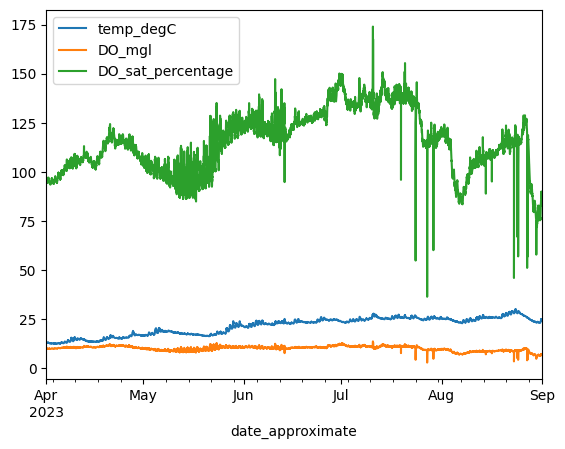

In [33]:
data_DO_CAB[data_DO_CAB.columns[1:]].plot()

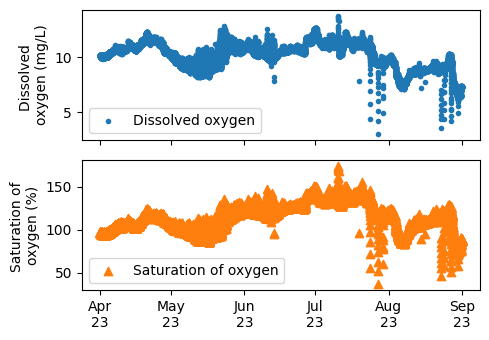

In [35]:
# Plot measurements from DO sonde 
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [5,3.5], sharey = False, sharex = True)

legend = ['Dissolved oxygen', 'Saturation of oxygen']
markers = ['.', '^']
pal = sns.color_palette("tab10", 10) # set colors (10 for 10 different colors)

# Create formatted date labels
# xlabels = ['Sep 22','Nov 22', 'Jan 23', 'Mar 23','May 23', 'Jul 23', 'Sep 23','Nov 23', 'Jan 24', 'Mar 24']
# xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]

for column in range(0, len(legend), 1):
    ax[column].scatter(data_DO_CAB.index, data_DO_CAB[data_DO_CAB.columns[column+2]], 
                       marker = markers[column], label = legend[column], color = pal.as_hex()[column])
    ax[column].legend()

# ax[2].set_xticklabels(xlabels_new)

# ax[0].yaxis.set_label_text('Water \ntemperature (°C)', size = 10)
ax[0].yaxis.set_label_text('Dissolved \noxygen (mg/L)', size = 10)
ax[1].yaxis.set_label_text('Saturation of \noxygen (%)', size = 10)

# Format date labels
myFmt = mdates.DateFormatter('%b\n%y') # date format with month in string!
ax[1].xaxis.set_major_formatter(myFmt)

plt.subplots_adjust(left = None, bottom = None, right = None, top = None, wspace = None, hspace = None)
plt.tight_layout()

# Save graph
# plt.savefig('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Thesis/Chapter05_water quality/DO_CAB_sonde_measurements.jpeg', dpi = 300, bbox_inches = 'tight')
plt.show();

# High-frequency water temperature


# CAB Location (WT)

In [13]:
## Routine to join multiple depths into one sheet
folder_cab = ('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/CAB_temperature_complete/CAB_01/')

# Import files from all field campaigns and join them into one dataframe
folders = sorted(glob.glob(folder_cab + '*/', recursive = True))
list_df_gaps_T = [] # creates empty list with dfs at every depth to count gaps!

# Routine for .txt data
for folder in range(0,5,1): # only the first 5 folders are .txt files!
  files = sorted(glob.glob(folders[folder] + 'txt/*.txt')) # Create list with names of all files in the folder
  for step in range(0,len(files),1): # read each file and work on the data
    data_temp = pd.read_csv(files[step], header = 1, delimiter = "\t", 
                            usecols = [0,1], names = ['date', 'temp_degC'], 
                            skiprows = [3,4,5]) # read files - space delimited, skips weird rows
    # do it for both temperature and lux columns - creates a list to be able to substitute comma by point
    txt = data_temp[data_temp.columns[1]]
    point_file = []
    for x in txt:
      x = re.sub(',', '.', x) # substitutes comma for point
      point_file.append(x) # makes a new list with point delimited numbers
    data_temp[data_temp.columns[1]] = point_file # substitutes comma delimited by point in the original dataframe
    data_temp[data_temp.columns[1]] = pd.to_numeric(data_temp[data_temp.columns[1]], 
                                                    errors='coerce') # transform to numeric ignoring errors (rows with no data)
    data_temp.rename(columns = {'temp_degC':('T_' + (os.path.basename(files[step])))}, 
                     inplace = True) # rename column by txt name on file
    data_temp.columns = data_temp.columns.str[:7] # keeps only the first 7 characters of the columns' names
    try: # needed as there are multiple data formats in the file
      data_temp['date'] = pd.to_datetime(data_temp['date'], format = "%Y-%m-%d %H:%M:%S") # Change date format to datetime
    except:
      data_temp['date'] = pd.to_datetime(data_temp['date'], format = "%y-%m-%d %H:%M:%S") # Change date format to datetime
    # Creates column with approximate date
    data_temp['hour'] = data_temp['date'].dt.strftime('%H').astype(int) # creates column with only hour
    data_temp['minute'] = data_temp['date'].dt.strftime('%M').astype('float') # creates column with only minute
    data_temp['round_min'] = np.where((data_temp['minute'] % 10) == 0, data_temp['minute'], 
                                      (data_temp['minute']/10).astype(int)*10)
    a = ["%02d" % x for x in data_temp['round_min']]
    data_temp['round_min'] = a
    data_temp['round_hours'] = (data_temp['hour'].astype(str) + ':' + data_temp['round_min'].astype(str))
    data_temp['date_approximate'] = pd.to_datetime(data_temp['date'].dt.strftime('%Y-%m-%d').astype(str) + ' ' + 
                                                   data_temp['round_hours'].astype(str), format = '%Y-%m-%d %H:%M')
    data_temp.drop(['date','hour', 'minute', 'round_min', 'round_hours'], axis = 1, inplace = True)
    
    # Join results
    if step == 0:
      measure_T = data_temp
    else:
      temp = data_temp
      measure_T = pd.merge(measure_T, temp, on = "date_approximate", how = "outer")
    # Creates a new list with dataframes for each depth to enable gap count
    df = pd.DataFrame.copy(data_temp)
    df['depth']=(str(folders[folder])[86:-1] + "_" + 
                 (os.path.basename(files[step]))) ## You can remove str() if everything in form is already a string
    list_df_gaps_T.append(df)
  if folder == 0:
    all_data_T = measure_T
  else:
    all_data_T = pd.concat([all_data_T, measure_T])

# Routine for .csv data
for folder in range(5,len(folders),1):
  # only the first 5 folders are .txt files!
  files = sorted(glob.glob(folders[folder] + 'csv/*.csv'))
  for step in range(0,len(files),1): # read each file and work on the data
    data_temp = pd.read_csv(files[step], header = 1, usecols = [1,2], 
                            names = ['date', 'temp_degC'], 
                            skiprows = [2,3,4]) # read files - space delimited, skips weird rows
    data_temp[data_temp.columns[1]] = pd.to_numeric(data_temp[data_temp.columns[1]], 
                                                    errors='coerce') # transform to numeric ignoring errors (rows with no data)
    data_temp.rename(columns = {'temp_degC':('T_' + (os.path.basename(files[step])))}, 
                     inplace = True) # rename column by txt name on file
    data_temp.columns = data_temp.columns.str[:7] # keeps only the first 7 characters of the columns' names
    try: # needed as there are multiple data formats in the file
      data_temp['date'] = pd.to_datetime(data_temp['date'], 
                                         format = "%m/%d/%y %I:%M:%S %p") # Change date format to datetime
    except:
      data_temp['date'] = pd.to_datetime(data_temp['date'], 
                                         format = "%m/%d/%y %H:%M") # Change date format to datetime
    # Creates column with approximate date
    data_temp['hour'] = data_temp['date'].dt.strftime('%H').astype(int) # creates column with only hour
    data_temp['minute'] = data_temp['date'].dt.strftime('%M').astype('float') # creates column with only minute
    data_temp['round_min'] = np.where((data_temp['minute'] % 10) == 0, data_temp['minute'], 
                                      (data_temp['minute']/10).astype(int)*10)
    a = ["%02d" % x for x in data_temp['round_min']]
    data_temp['round_min'] = a
    data_temp['round_hours'] = (data_temp['hour'].astype(str) + ':' + data_temp['round_min'].astype(str))
    data_temp['date_approximate'] = pd.to_datetime(data_temp['date'].dt.strftime('%Y-%m-%d').astype(str) + ' ' + 
                                                   data_temp['round_hours'].astype(str), format = '%Y-%m-%d %H:%M')
    data_temp.drop(['date', 'hour', 'minute', 'round_min', 'round_hours'], axis = 1, inplace = True)
    
    if step == 0:
      measure_T = data_temp
    else:
      measure_T = pd.merge(measure_T, data_temp, on = "date_approximate", how = "inner")
    df = pd.DataFrame.copy(data_temp) # Creates a new list with dataframes for each depth to enable gap count
    df['depth']=(str(folders[folder])[86:-1] + "_" + (os.path.basename(files[step]))) 
    list_df_gaps_T.append(df)
  all_data_T = pd.concat([all_data_T, measure_T])

all_data_T.set_index('date_approximate', inplace = True)
all_data_T = all_data_T.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00'] # calibration period
all_data_T = all_data_T.reset_index()

all_data_T.head()

,date_approximate,T_CAB_0,T_CAB_1,T_CAB_2,T_CAB_3,T_CAB_4,T_CAB_5,T_CAB_7,T_CAB_8,T_CAB_9,T_CAB_6
0,2022-09-09 00:00:00,25.74,NaN,NaN,NaN,25.31,25.44,NaN,NaN,24.32,NaN
1,2022-09-09 00:10:00,25.74,NaN,NaN,NaN,25.31,25.44,NaN,NaN,24.36,NaN
2,2022-09-09 00:20:00,25.69,NaN,NaN,NaN,25.31,25.44,NaN,NaN,24.36,NaN
3,2022-09-09 00:30:00,25.69,NaN,NaN,NaN,25.31,25.39,NaN,NaN,24.36,NaN
4,2022-09-09 00:40:00,25.65,NaN,NaN,NaN,25.31,25.39,NaN,NaN,24.36,NaN


In [31]:
# Water temperature ratio - surface T over bottom T
WT_ratio_CAB = all_data_T.copy()
WT_ratio_CAB['WT_ratio_CAB'] = (WT_ratio_CAB['T_CAB_0'] / WT_ratio_CAB['T_CAB_9'])
WT_ratio_CAB = WT_ratio_CAB[['date_approximate', 'WT_ratio_CAB']]
WT_ratio_CAB.dropna(inplace = True)
WT_ratio_CAB = WT_ratio_CAB[WT_ratio_CAB['date_approximate'] > '2023-01-25 00:00:00']
WT_ratio_CAB.set_index('date_approximate', inplace = True)
WT_ratio_CAB.head(2)

,WT_ratio_CAB
date_approximate,
2023-01-25 00:10:00,1.034217
2023-01-25 00:20:00,1.034217


In [32]:
# import modelled WT_ratio
WT_ratio_FPV49 = pd.read_csv('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/WT_ratio_FPV49.csv')
WT_ratio_FPV49['time'] = pd.to_datetime(WT_ratio_FPV49['time'], format = 'mixed')
WT_ratio_FPV49.rename(columns = {'time':'date_approximate'}, inplace = True)
WT_ratio_FPV49.set_index('date_approximate', inplace = True)
WT_ratio_FPV49.head(2)

,WT_surface,WT_bottom,WT_ratio
date_approximate,,,
2022-09-09 00:00:00,25.657999,24.474388,1.048361
2022-09-09 06:00:00,25.181696,24.486795,1.028379


In [33]:
WT_ratio_compare = WT_ratio_CAB.join(WT_ratio_FPV49, how = 'inner')
WT_ratio_compare.head(2)

,WT_ratio_CAB,WT_surface,WT_bottom,WT_ratio
date_approximate,,,,
2023-01-25 06:00:00,1.017108,0.656900,3.510298,0.187135
2023-01-25 12:00:00,1.034812,0.657308,3.510253,0.187254


<ipython-input-43-fb34f0c9deda>:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


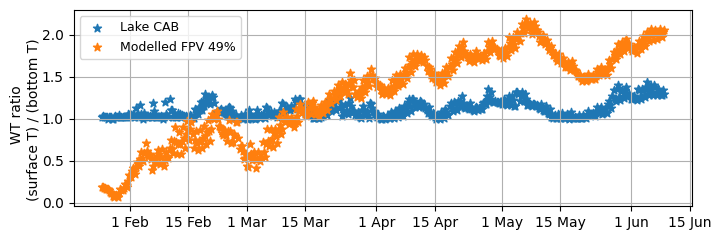

In [43]:
# Plot graph with WT per depth
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [7,2.5], sharex = False, sharey = True)
pal = sns.color_palette("tab10", 11)

ax.scatter(WT_ratio_compare.index, WT_ratio_compare['WT_ratio_CAB'],
           color = pal.as_hex()[0], zorder = 1, marker = '*',
           label = 'Lake CAB')

ax.scatter(WT_ratio_compare.index, WT_ratio_compare['WT_ratio'],
           color = pal.as_hex()[1], zorder = 1, marker = '*',
           label = 'Modelled FPV 49%')

ax.grid(True, zorder = -1)

ax.legend(loc="upper left", ncol = 1, fontsize = 9, 
          frameon = True, columnspacing = 0.01)._legend_box.align = "left"

# ax[0].text(19485, 4.5, '(a) Before FPV', color = 'k', fontsize = 10)
# ax[1].text(19485, 4.5, '(b) After FPV', color = 'k', fontsize = 10)

# Add formatted date labels
xlabels = ['1 Feb','15 Feb', '1 Mar', '15 Mar','1 Apr', '15 Apr', '1 May','15 May', '1 Jun', '15 Jun']
ax.set_xticklabels(xlabels)

# ax.set_ylim(0.9,1.9)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.5, u'             WT ratio\n(surface T) / (bottom T)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
plt.savefig('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/WT_ratio_lakeCAB_FPV49.jpeg', dpi=600, bbox_inches='tight')

plt.show();

**Export csv file**

In [32]:
all_data_T.to_csv(core_path + 'all_data_T.csv')

**Checks gaps**

In [14]:
# Creates date list at 10min interval - start and end dates according to measurements
from datetime import datetime, timedelta # need to call again for the code to work...

start_date = all_data_T.iloc[0,0] # Locates initial measurement
end_date = all_data_T.iloc[-1,0] # Locates final measurement
timedelta = timedelta(minutes = 10) # Creates time interval - frequency of measurements

date_list = []
curr_date = start_date

while curr_date <= end_date:
    date_list.append(curr_date)
    curr_date = curr_date + timedelta

# date_list

# Transforms list to dataframe
dates_complete_T = pd.DataFrame(date_list)
dates_complete_T.rename(columns = {dates_complete_T.columns[0]:'dates_complete_T'}, inplace = True)
dates_complete_T = pd.DataFrame(dates_complete_T['dates_complete_T'].astype(str)) # transforms data to string to be able to join with other data
dates_complete_T.set_index('dates_complete_T', inplace = True)
dates_complete_T.head(2)

""
dates_complete_T
2022-09-09 00:00:00
2022-09-09 00:10:00


In [37]:
# Export to csv
dates_complete_T.to_csv(core_path + 'dates_complete_T.csv')

In [15]:
# Creates complete dataset of measurements + gaps for each depth - one dataframe per depth
List = all_data_T.columns[1:]
gaps_list = []
Dictionary = {}

for i in List:
    Dictionary[i] = pd.DataFrame()
    Dictionary[i] = all_data_T[[i,'date_approximate']]
    Dictionary[i] = Dictionary[i].dropna()
    Dictionary[i]['date_approximate'] = Dictionary[i]['date_approximate'].astype(str)
    Dictionary[i].set_index('date_approximate', inplace = True)
    Dictionary[i] = dates_complete_T.join(Dictionary[i], how="outer")

# print("Created multiple dataframes in a loop:\n", Dictionary)

# Counts gaps and lists them
List = all_data_T.columns[1:].sort_values()
print('Percentage of gaps per depth - calibration period')
print(' ')

for i in List:
  gaps = Dictionary[i][Dictionary[i].columns[0]].isna().sum().sum()
  total_values = Dictionary[i].shape[0]
  gaps_list.append((gaps/total_values)*100)
  print(i + ': ' + '%0.4f%%' %((gaps/total_values)*100))

Percentage of gaps per depth - calibration period
 
T_CAB_0: 6.3240%
T_CAB_1: 7.6326%
T_CAB_2: 7.6326%
T_CAB_3: 7.6326%
T_CAB_4: 6.3240%
T_CAB_5: 6.3265%
T_CAB_6: 7.6326%
T_CAB_7: 7.6326%
T_CAB_8: 7.6326%
T_CAB_9: 33.3885%


In [30]:
# Export all to excel files
# List = all_data_T.columns[0:-2]

# for i in List:
#     Dictionary[i].to_csv(((Dictionary[i].columns[1]) + '_deltaT' + '.csv'))


# BIS Location

In [31]:
## Routine to join multiple depths into one sheet
folder_bis = ('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/CAB_temperature_complete/CAB_BIS/')

# Import files from all field campaigns and join them into one dataframe
folders = sorted(glob.glob(folder_cab + '*/', recursive = True))
list_df_gaps_T_BIS = [] # creates empty list with dfs at every depth to count gaps!

# Routine for .txt data
for folder in range(0,2,1): # only the first 2 folders are .txt files!
  files = sorted(glob.glob(folders[folder] + 'txt/*.txt')) # Create list with names of all files in the folder
  for step in range(0,len(files),1): # read each file and work on the data
    data_temp = pd.read_csv(files[step], header = 1, delimiter = "\t", usecols = [0,1], names = ['date', 'temp_degC'], skiprows = [3,4,5]) # read files - space delimited, skips weird rows
    txt = data_temp[data_temp.columns[1]] # do it for both temperature and lux columns - creates a list to be able to substitute comma by point
    point_file = []
    for x in txt:
      x = re.sub(',', '.', x) # substitutes comma for point
      point_file.append(x) # makes a new list with point delimited numbers
    data_temp[data_temp.columns[1]] = point_file # substitutes comma delimited by point in the original dataframe
    data_temp[data_temp.columns[1]] = pd.to_numeric(data_temp[data_temp.columns[1]], errors='coerce') # transforms dtype to numeric ignoring errors (rows with no data)
    data_temp.rename(columns = {'temp_degC':('T_' + (os.path.basename(files[step])))}, inplace = True) # rename column by txt name on file
    data_temp.columns = data_temp.columns.str[:7] # keeps only the first 7 characters of the columns' names
    try: # needed as there are multiple data formats in the file
      data_temp['date'] = pd.to_datetime(data_temp['date'], format = "%Y-%m-%d %H:%M:%S") # Change date format to datetime
    except:
      data_temp['date'] = pd.to_datetime(data_temp['date'], format = "%y-%m-%d %H:%M:%S") # Change date format to datetime
    # Creates column with approximate date
    data_temp['hour'] = data_temp['date'].dt.strftime('%H').astype(int) # creates column with only hour
    data_temp['minute'] = data_temp['date'].dt.strftime('%M').astype('float') # creates column with only minute
    data_temp['round_min'] = np.where((data_temp['minute'] % 10) == 0, data_temp['minute'], 
                                      (data_temp['minute']/10).astype(int)*10)
    a = ["%02d" % x for x in data_temp['round_min']]
    data_temp['round_min'] = a
    data_temp['round_hours'] = (data_temp['hour'].astype(str) + ':' + data_temp['round_min'].astype(str))
    data_temp['date_approximate'] = pd.to_datetime(data_temp['date'].dt.strftime('%Y-%m-%d').astype(str) + ' ' + 
                                                   data_temp['round_hours'].astype(str), format = '%Y-%m-%d %H:%M')
    data_temp.drop(['date','hour', 'minute', 'round_min', 'round_hours'], axis = 1, inplace = True)
    
    if step == 0:
      measure_T = data_temp
    else:
      temp = data_temp
      measure_T = pd.merge(measure_T, temp, on = "date_approximate", how = "outer")
    # Creates a new list with dataframes for each depth to enable gap count
    df = pd.DataFrame.copy(data_temp)
    df['depth']=(str(folders[folder])[86:-1] + "_" + (os.path.basename(files[step]))) ## You can remove str() if everything in form is already a string
    list_df_gaps_T_BIS.append(df)
  if folder == 0:
    all_data_T_BIS = measure_T
  else:
    all_data_T_BIS = pd.concat([all_data_T_BIS, measure_T])

# Routine for .csv data
for folder in range(2,len(folders),1):
  # only the first 2 folders are .txt files!
  files = sorted(glob.glob(folders[folder] + 'csv/*.csv'))
  for step in range(0,len(files),1): # read each file and work on the data
    data_temp = pd.read_csv(files[step], header = 1, usecols = [1,2], names = ['date', 'temp_degC'], skiprows = [2,3,4]) # read files - space delimited, skips weird rows
    data_temp[data_temp.columns[1]] = pd.to_numeric(data_temp[data_temp.columns[1]], errors='coerce') # transforms dtype to numeric ignoring errors (rows with no data)
    data_temp.rename(columns = {'temp_degC':('T_' + (os.path.basename(files[step])))}, inplace = True) # rename column by txt name on file
    data_temp.columns = data_temp.columns.str[:7] # keeps only the first 7 characters of the columns' names
    try: # needed as there are multiple data formats in the file
      data_temp['date'] = pd.to_datetime(data_temp['date'], format = "%m/%d/%y %I:%M:%S %p") # Change date format to datetime
    except:
      data_temp['date'] = pd.to_datetime(data_temp['date'], format = "%m/%d/%y %H:%M") # Change date format to datetime
    # Creates column with approximate date
    data_temp['hour'] = data_temp['date'].dt.strftime('%H').astype(int) # creates column with only hour
    data_temp['minute'] = data_temp['date'].dt.strftime('%M').astype('float') # creates column with only minute
    data_temp['round_min'] = np.where((data_temp['minute'] % 10) == 0, data_temp['minute'], 
                                      (data_temp['minute']/10).astype(int)*10)
    a = ["%02d" % x for x in data_temp['round_min']]
    data_temp['round_min'] = a
    data_temp['round_hours'] = (data_temp['hour'].astype(str) + ':' + data_temp['round_min'].astype(str))
    data_temp['date_approximate'] = pd.to_datetime(data_temp['date'].dt.strftime('%Y-%m-%d').astype(str) + ' ' + 
                                                   data_temp['round_hours'].astype(str), format = '%Y-%m-%d %H:%M')
    data_temp.drop(['date', 'hour', 'minute', 'round_min', 'round_hours'], axis = 1, inplace = True)
    
    if step == 0:
      measure_T = data_temp
    else:
      measure_T = pd.merge(measure_T, data_temp, on = "date_approximate", how = "outer")
    df = pd.DataFrame.copy(data_temp) # Creates a new list with dataframes for each depth to enable gap count
    df['depth']=(str(folders[folder])[86:-1] + "_" + (os.path.basename(files[step]))) ## You can remove str() if everything in form is already a string
    list_df_gaps_T_BIS.append(df)
  all_data_T_BIS = pd.concat([all_data_T_BIS, measure_T])

all_data_T_BIS.set_index('date_approximate', inplace = True)
all_data_T_BIS = all_data_T_BIS.loc['2022-09-27 00:00:00':'2023-06-08 18:00:00'] # calibration period
all_data_T_BIS = all_data_T_BIS.reset_index()

all_data_T_BIS.head()

,date_approximate,T_CAB_0,T_CAB_1,T_CAB_2,T_CAB_3,T_CAB_4,T_CAB_5,T_CAB_7,T_CAB_8,T_CAB_9,T_CAB_6
0,2022-09-27 00:00:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-09-27 00:10:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-09-27 00:20:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-09-27 00:30:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-09-27 00:40:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Export csv file**

In [33]:
all_data_T_BIS.to_csv(core_path + 'all_data_T_BIS.csv')

**Checks gaps**

In [34]:
# Creates date list at 10min interval - start and end dates according to measurements
from datetime import datetime, timedelta # need to call again for the code to work...

start_date = all_data_T_BIS.iloc[0,0] # Locates initial measurement
end_date = all_data_T_BIS.iloc[-1,0] # Locates final measurement
timedelta = timedelta(minutes = 10) # Creates time interval - frequency of measurements

date_list = []
curr_date = start_date

while curr_date <= end_date:
    date_list.append(curr_date)
    curr_date = curr_date + timedelta

# date_list

# Transforms list to dataframe
dates_complete_T_BIS = pd.DataFrame(date_list)
dates_complete_T_BIS.rename(columns = {dates_complete_T_BIS.columns[0]:'dates_complete_T_BIS'}, inplace = True)
dates_complete_T_BIS = pd.DataFrame(dates_complete_T_BIS['dates_complete_T_BIS'].astype(str)) # transforms data to string to be able to join with other data
dates_complete_T_BIS.set_index('dates_complete_T_BIS', inplace = True)
dates_complete_T_BIS.head()

""
dates_complete_T_BIS
2022-09-27 00:00:00
2022-09-27 00:10:00
2022-09-27 00:20:00
2022-09-27 00:30:00
2022-09-27 00:40:00


In [35]:
# Creates complete dataset of measurements + gaps_BIS for each depth - one dataframe per depth
List = all_data_T_BIS.columns[1:]
gaps_BIS_list = []
Dictionary_BIS = {}

for i in List:
    Dictionary_BIS[i] = pd.DataFrame()
    Dictionary_BIS[i] = all_data_T_BIS[[i,'date_approximate']]
    Dictionary_BIS[i] = Dictionary_BIS[i].dropna()
    Dictionary_BIS[i]['date_approximate'] = Dictionary_BIS[i]['date_approximate'].astype(str)
    Dictionary_BIS[i].set_index('date_approximate', inplace = True)
    Dictionary_BIS[i] = dates_complete_T_BIS.join(Dictionary_BIS[i], how="outer")

# print("Created multiple dataframes in a loop:\n", Dictionary_BIS)

# Counts gaps_BIS and lists them
List = all_data_T_BIS.columns[1:].sort_values()
print('Percentage of gaps in BIS location per depth - calibration period')
print(' ')

for i in List:
  gaps_BIS = Dictionary_BIS[i][Dictionary_BIS[i].columns[0]].isna().sum().sum()
  total_values_BIS = Dictionary_BIS[i].shape[0]
  gaps_BIS_list.append((gaps_BIS/total_values_BIS)*100)
  print(i + ': ' + '%0.5f%%' %((gaps_BIS/total_values_BIS)*100))

Percentage of gaps in BIS location per depth - calibration period
 
T_CAB_0: 0.01635%
T_CAB_1: 0.01635%
T_CAB_2: 1.10393%
T_CAB_3: 1.10390%
T_CAB_4: 1.10660%
T_CAB_5: 1.10660%
T_CAB_6: 1.10660%
T_CAB_7: 1.10660%
T_CAB_8: 1.10660%
T_CAB_9: 30.07496%
